# **Raquel Marques - GeoStatistics Project**

Last Updated: 2026-08-09

---

## Project Objective

This project analyzes the spatial distribution of households, points of sale (PDVs), and
revenue (FATURAM) across São Paulo's districts to support retail network planning,
identifying areas of high customer concentration, mapping each PDV's market/influence
zone, and testing whether household density shows statistically significant spatial
clustering, in order to guide decisions on **where to expand or reinforce the
point-of-sale network**.

<br>

**pt-br**:

<span style="color:gray">
Este projeto analisa a distribuição espacial de domicílios, pontos de venda (PDVs) e
faturamento nos distritos de São Paulo para apoiar o planejamento da rede de varejo,
identificando áreas de maior concentração de clientes, mapeando a zona de influência de
cada PDV, e testando se a densidade populacional apresenta agrupamento espacial
estatisticamente significativo, de forma a orientar decisões sobre **onde expandir ou
reforçar a rede de pontos de venda**.
</span>

# LIBRARY

In [147]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from scipy.stats import gaussian_kde
from scipy.spatial import Voronoi, cKDTree
from shapely.geometry import Polygon

from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

from pykrige.ok import OrdinaryKriging

plt.rcParams["figure.dpi"] = 100

# PATH

In [148]:
main_dir = os.path.join(os.path.expanduser("~"), 
                           "OneDrive", 
                           "Project_Code")

project_dir = os.path.join(main_dir,
                           "ASN-DSA-T5", 
                           "35-GE")

# FILES

In [149]:
localidade = gpd.read_file(os.path.join(project_dir, "data", "Localidades", "distritos_sp.gpkg"))
enderecos = gpd.read_file(os.path.join(project_dir, "data", "Enderecos", "pontos_sp.shp"))
pontos_venda = gpd.read_file(os.path.join(project_dir, "data", "Mapas_", "pdv_sp.gpkg"))


In [150]:
# check files top rows
print("Localidade:")
print(localidade.head())

print("\nEndereços:")
print(enderecos.head())

print("\nPontos de Venda:")
print(pontos_venda.head())

Localidade:
    id CD_REGIAO NM_REGIAO CD_UF      NM_UF   CD_MUN     NM_MUN    CD_DIST  \
0  894         3   Sudeste    35  São Paulo  3550308  São Paulo  355030801   
1  895         3   Sudeste    35  São Paulo  3550308  São Paulo  355030802   
2  896         3   Sudeste    35  São Paulo  3550308  São Paulo  355030803   
3  897         3   Sudeste    35  São Paulo  3550308  São Paulo  355030804   
4  898         3   Sudeste    35  São Paulo  3550308  São Paulo  355030805   

             NM_DIST CD_RGINT   NM_RGINT  CD_RGI     NM_RGI CD_CONCURB  \
0          Água Rasa     3501  São Paulo  350001  São Paulo    3550308   
1  Alto de Pinheiros     3501  São Paulo  350001  São Paulo    3550308   
2         Anhanguera     3501  São Paulo  350001  São Paulo    3550308   
3         Aricanduva     3501  São Paulo  350001  São Paulo    3550308   
4        Artur Alvim     3501  São Paulo  350001  São Paulo    3550308   

     NM_CONCURB                                           geometry  
0  Sã

In [151]:
print("CRS distritos :", localidade.crs)
print("CRS enderecos :", enderecos.crs)
print("CRS PDV       :", pontos_venda.crs)

CRS distritos : EPSG:4674
CRS enderecos : EPSG:3857
CRS PDV       : EPSG:4326


## Map Visualization

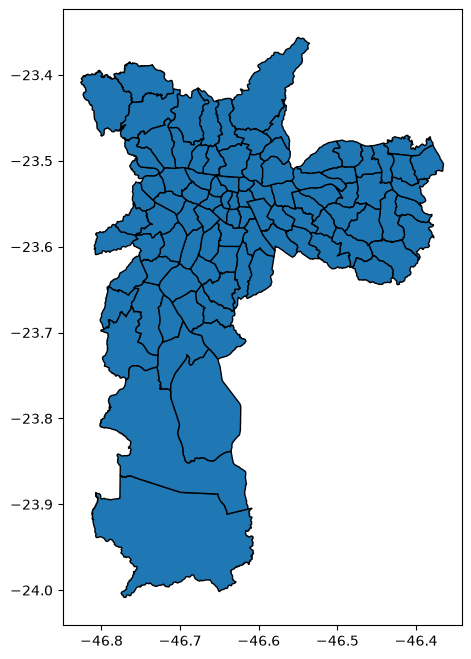

In [152]:
localidade.plot(edgecolor="black", figsize=(8,8)) # São Paulo Districts
plt.show()


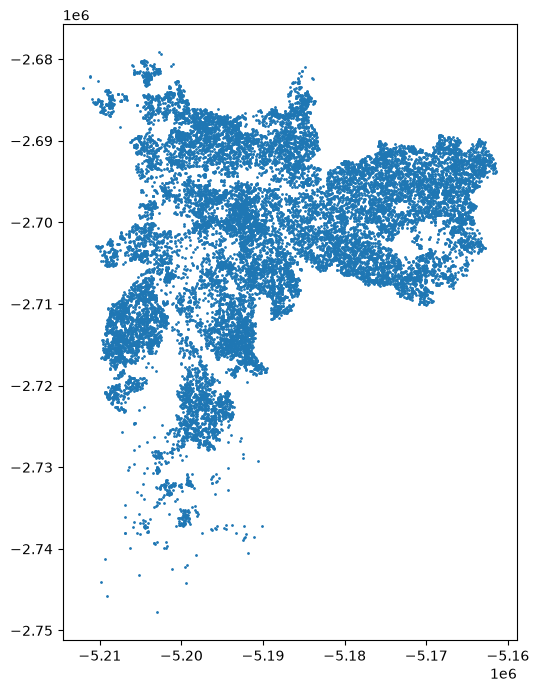

In [153]:
enderecos.plot(markersize=1, figsize=(8,8)) # Points located in São Paulo (homes and businesses)
plt.show()

## Select Points classified as "*home*"

In [154]:
# selecting only homes
domicilios = enderecos[enderecos["COD_ESP"] == 1].copy()
print("\nQtd domicílios:", len(domicilios))


Qtd domicílios: 17100


# EXERCISE

## Question 1: Reference System
Why is it necessary to transform data to a projected coordinate system (e.g., EPSG:3857 or UTM) before calculating distances, buffers, or performing interpolations?


#### Answer:
Geographic data often comes in geographic coordinates (degrees), such as EPSG: 4326 (latitude/longitude). In this system, 1 degree does not correspond to a fixed distance in meters; the distance between longitudes changes according to latitude. This invalidates calculations of:
- Euclidean distance (the formula sqrt((x2-x1)² + (y2-y1)²) does not return meters in degrees)
- Buffers (a buffer of "500" in degrees does not represent 500 meters, and the circle shape is distorted)
- Interpolation (IDW/Kriging), which directly depends on correct distances between points to weight neighboring values

A projected coordinate system (UTM or EPSG: 3857) converts coordinates to a Cartesian plane in meters, allowing metric and geometric operations to be calculated correctly and consistently throughout the study area.

<br>

**pt-br**:

<span style="color:gray">
Em graus (EPSG:4326/4674), 1 grau não equivale a uma distância fixa em metros (a área de cada grau varia com a latitude), então distâncias, buffers e interpolações calculadas nesse sistema saem distorcidas/erradas. 
Projetando para um sistema métrico (EPSG:3857 ou UTM) as coordenadas passam a estar em metros num plano cartesiano, permitindo cálculos geométricos corretos.

Demonstração abaixo: 
- mapa de sobreposição sem converter (distritos EPSG:4674 e enderecos EPSG:3857)
    - *não é plotado corretamente*
- mapa de sobreposição depois da conversão (ambos EPSG:3857)
    - *os pontos de domicílios são plotados corretamente nos distritos*
- mesma distância entre dois pontos calculada em graus vs. em metros (projetado)
</span>

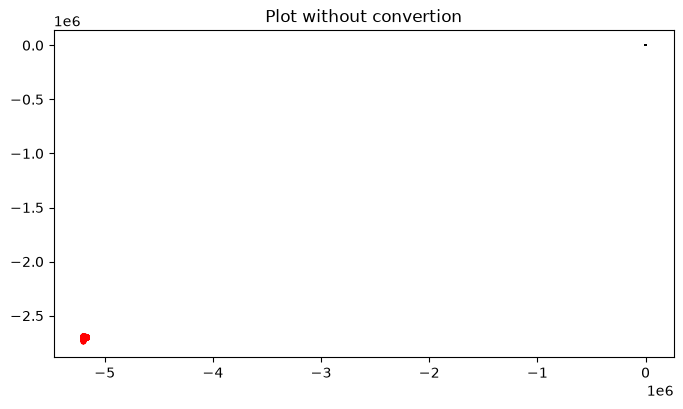

In [155]:
# Plot: without converting
ax = localidade.plot(facecolor="white",
                     edgecolor="black",
                     figsize=(8,8))

domicilios.plot(ax=ax,
                color="red",
                markersize=2)
plt.title("Plot without convertion")
plt.show()

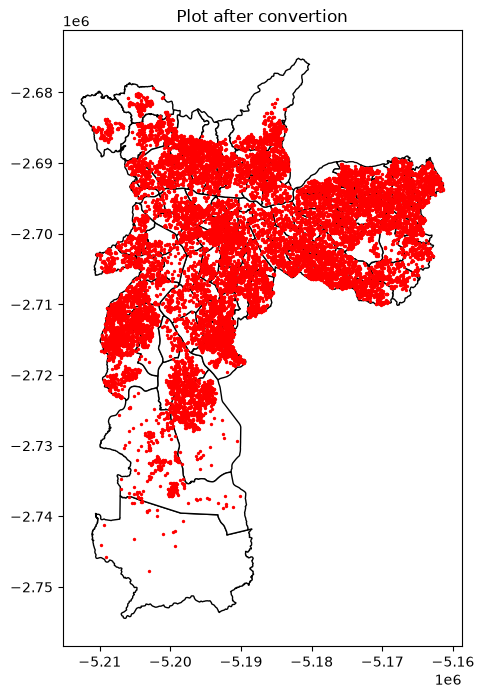

In [156]:
# Convertion
localidade3857 = localidade.to_crs(3857)
domicilios3857 = domicilios.to_crs(3857)


# Plot: after converting
ax = localidade3857.plot(facecolor="white",
                     edgecolor="black",
                     figsize=(8,8))

domicilios3857.plot(ax=ax,
                color="red",
                markersize=2)
plt.title("Plot after convertion")
plt.show()

In [157]:
# Method 1: Check the CRS definition
print("Base localidade")
print(localidade.crs)  # Shows EPSG:4326 or similar
print(localidade.crs.axis_info)  # Shows units for each axis

# Method 2: Check if it's geographic vs projected
print(f"\nUsing `is_geografic`, Degrees = TRUE and Meters = FALSE. Base: localidade: {localidade.crs.is_geographic}")  # True = degrees, False = projected (meters)
print(f"\nUsing `is_geografic`, Degrees = TRUE and Meters = FALSE. Base: localidade3857: {localidade3857.crs.is_geographic}")  # False

# Method 3: Check the units directly
print("\nBase localidade")
for axis in localidade.crs.axis_info:
    print(f" Axis: {axis.name}, Unit: {axis.unit_name}")

Base localidade
EPSG:4674
[Axis(name=Geodetic latitude, abbrev=Lat, direction=north, unit_auth_code=EPSG, unit_code=9122, unit_name=degree), Axis(name=Geodetic longitude, abbrev=Lon, direction=east, unit_auth_code=EPSG, unit_code=9122, unit_name=degree)]

Using `is_geografic`, Degrees = TRUE and Meters = FALSE. Base: localidade: True

Using `is_geografic`, Degrees = TRUE and Meters = FALSE. Base: localidade3857: False

Base localidade
 Axis: Geodetic latitude, Unit: degree
 Axis: Geodetic longitude, Unit: degree


In [158]:
def what_are_my_units(gdf):
    """Super simple function with nice output"""

    # Get the variable name
    var_name = [name for name, value in globals().items() if value is gdf]
    var_name = var_name[0] if var_name else "DataFrame"

    try:
        if gdf.crs.is_geographic:
            units = "DEGREES"
            tip = "💡 Convert to projected CRS for calculations"
        else:
            units = "METERS"
            tip = "✅ Ready for distance/area calculations"
    except:
        units = "UNKNOWN"
        tip = "⚠️ Define a CRS first"
    
    epsg = gdf.crs.to_epsg() if hasattr(gdf.crs, 'to_epsg') else None
    
    print(f"""📍Data: {var_name}
      CRS: {gdf.crs}
      EPSG: {epsg if epsg else 'Not available'}
      UNITS: {units}
      {tip}""")
    # return units

# Usage
what_are_my_units(localidade)
what_are_my_units(domicilios)
what_are_my_units(pontos_venda)

📍Data: localidade
      CRS: EPSG:4674
      EPSG: 4674
      UNITS: DEGREES
      💡 Convert to projected CRS for calculations
📍Data: domicilios
      CRS: EPSG:3857
      EPSG: 3857
      UNITS: METERS
      ✅ Ready for distance/area calculations
📍Data: pontos_venda
      CRS: EPSG:4326
      EPSG: 4326
      UNITS: DEGREES
      💡 Convert to projected CRS for calculations


In [159]:
# Demonstration - Projection effect on distance
p1 = localidade.geometry.iloc[0]
p2 = localidade.geometry.iloc[1]

dist_graus = p1.distance(p2)  # in degrees - MAKES NO SENSE as fisical distance
print(f"Distância em graus (CRS original - {localidade.crs}): {dist_graus:.6f}")

localidade_3857 = localidade.to_crs(3857)
p1_m = localidade_3857.geometry.iloc[0]
p2_m = localidade_3857.geometry.iloc[1]
dist_m = p1_m.distance(p2_m)
print(f"Distância em metros (EPSG:3857)  : {dist_m:.2f} m")

Distância em graus (CRS original - EPSG:4674): 0.104481
Distância em metros (EPSG:3857)  : 11665.34 m


In [160]:
# Demonstration - Projection effect on distance
p1 = pontos_venda.geometry.iloc[0]
p2 = pontos_venda.geometry.iloc[1]

dist_graus = p1.distance(p2)  # in degrees - MAKES NO SENSE as fisical distance
print(f"Distância em graus (CRS original - {pontos_venda.crs}): {dist_graus:.6f}")

pontos_venda_3857 = pontos_venda.to_crs(3857)
p1_m = pontos_venda_3857.geometry.iloc[0]
p2_m = pontos_venda_3857.geometry.iloc[1]
dist_m = p1_m.distance(p2_m)
print(f"Distância em metros (EPSG:3857)  : {dist_m:.2f} m")

Distância em graus (CRS original - EPSG:4326): 0.102443
Distância em metros (EPSG:3857)  : 12278.16 m


## Question 2: Spatial Junction
What is the purpose of the function below?

```python
gpd.sjoin(domicilios, localidade, predicate="within")
```


#### Answer:
The goal is to associate each household with the polygon (locality/district) within which it is geographically contained, joining the attributes of the polygon layer (locality) to the point layer (households) whenever the point is within the polygon. It is a join based on spatial relationship (and not on a common key), useful for aggregating or classifying points by administrative region.

<br>

**pt-br**:

<span style="color:gray">
A função associa a cada domicílio o(s) atributo(s) do distrito (polígono) em que ele está contido, permitindo, por exemplo, contar/agregar domicílios por distrito.
</span>

            NM_DIST  qtd_domicilios
29           Grajaú             643
42    Jardim Ângela             494
18    Capão Redondo             428
21    Cidade Ademar             400
75        Sapopemba             400
67           Sacomã             396
10      Brasilândia             391
45  Jardim São Luís             365
80         Tremembé             339
16      Campo Limpo             322


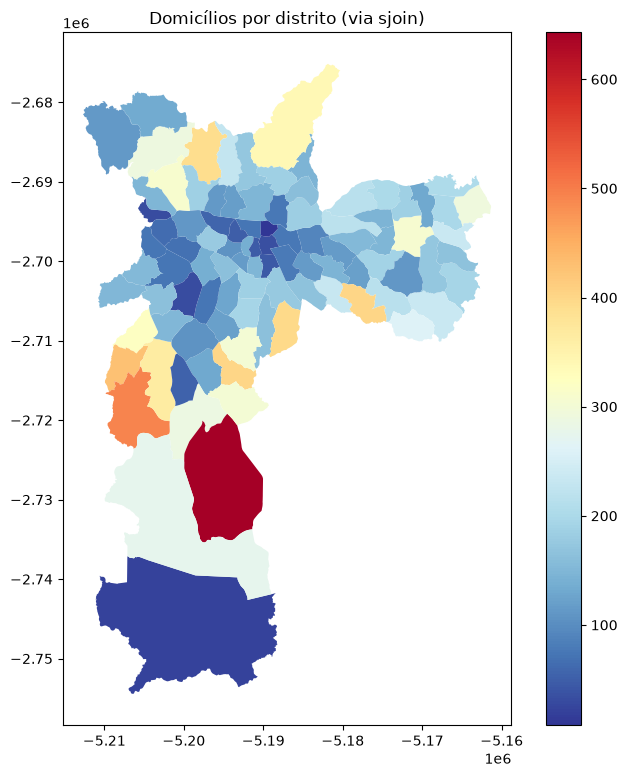

In [161]:
# Spacial Junction + counting by district
localidade3857 = localidade.to_crs(3857)
domicilios3857 = domicilios.to_crs(3857)

join = gpd.sjoin(domicilios3857, localidade3857, predicate="within", how="left")

contagem = join.groupby(join.index_right).size()
localidade3857["qtd_domicilios"] = (
    contagem.reindex(localidade3857.index).fillna(0).astype(int)
)

print(localidade3857[["NM_DIST", "qtd_domicilios"]].sort_values(
    "qtd_domicilios", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 9))
localidade3857.plot(column="qtd_domicilios", cmap="RdYlBu_r", legend=True, ax=ax)
ax.set_title("Domicílios por distrito (via sjoin)")
plt.show()

## Question 3: Buffer
When creating a 500-meter buffer around points of sale, what does the generated polygon represent?

#### Answer:
The generated polygon (a circle with a 500 m radius around each point of sale) represents the area of ​​influence (or coverage) of that POS. For example, the zone within which the point of sale is assumed to serve, attract, or impact customers/households. It is typically used to identify how many households, competitors, or other points of interest are within a proximity radius.

<br>

**pt-br**:

<span style="color:gray">
O polígono do buffer de 500 m representa a área de influência/ cobertura de cada ponto de venda. A zona dentro da qual se considera que o PDV atende ou impacta os domicílios/clientes próximos.

</span>

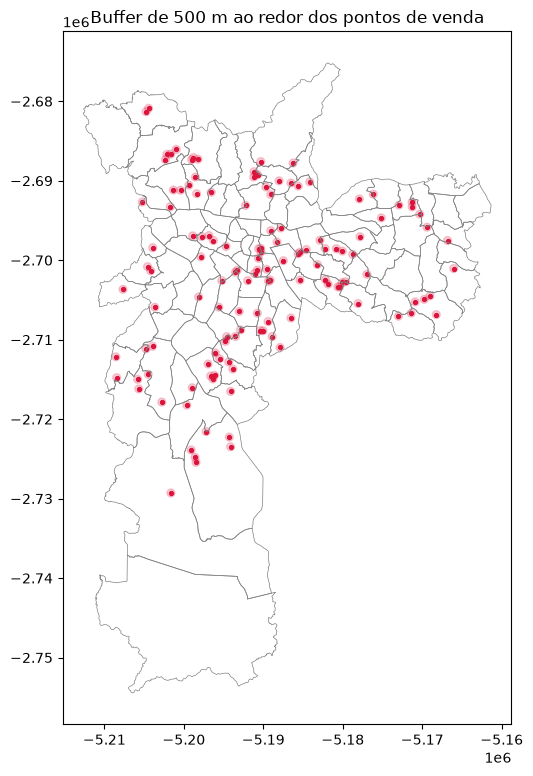


Domicílios dentro do buffer de 500 m por PDV:
count    132.000000
mean      12.098485
std        6.428538
min        0.000000
25%        7.000000
50%       12.000000
75%       15.250000
max       29.000000
dtype: float64


In [162]:
# 500m Buffer around PDV (pontos de venda)
pontos_venda3857 = pontos_venda.to_crs(3857)

buffer_pdv = pontos_venda3857.copy()
buffer_pdv["geometry"] = buffer_pdv.buffer(500)

fig, ax = plt.subplots(figsize=(9, 9))
localidade3857.boundary.plot(ax=ax, color="gray", linewidth=0.5)
buffer_pdv.plot(ax=ax, facecolor="crimson", edgecolor="crimson", alpha=0.2)
pontos_venda3857.plot(ax=ax, color="crimson", markersize=8)
ax.set_title("Buffer de 500 m ao redor dos pontos de venda")
plt.show()

# how many domiciles we have inside each buffer
dom_no_buffer = gpd.sjoin(domicilios3857, buffer_pdv, predicate="within")
# qtd_por_pdv = dom_no_buffer.groupby("index_right").size()
qtd_por_pdv = dom_no_buffer.groupby("index_right").size().reindex(buffer_pdv.index).fillna(0)
print("\nDomicílios dentro do buffer de 500 m por PDV:")
print(qtd_por_pdv.describe())

## Question 4: Kernel Density
The main purpose of a Kernel Density Map is:


#### Answer:
The Kernel Density Map (KDE) is primarily intended to visually identify areas of concentration or clustering of points (hotspots), smoothing the point distribution onto a continuous density surface.

It is very useful for detecting regions of higher intensity of a phenomenon (e.g., concentration of households, occurrences, sales) without relying on arbitrary administrative boundaries.

<br>

**pt-br**:

<span style="color:gray">
O mapa de densidade Kernel tem como finalidade principal identificar visualmente áreas de concentração/aglomeração de pontos (hotspots), suavizando a distribuição pontual numa superfície contínua de densidade.

</span>

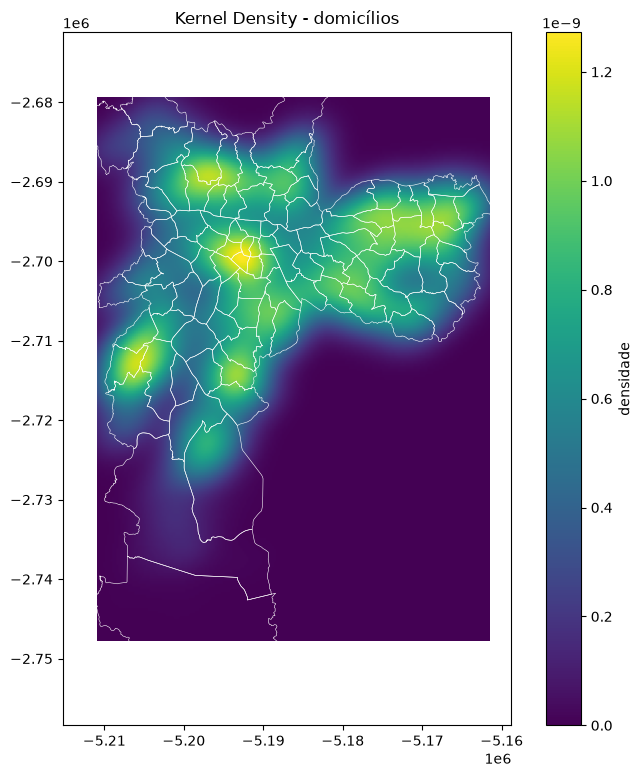

In [163]:
# domiciles Kernel Density
x = domicilios3857.geometry.x
y = domicilios3857.geometry.y
xy = np.vstack([x, y])
kde = gaussian_kde(xy)

xmin, ymin, xmax, ymax = domicilios3857.total_bounds
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
z = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 9))
plt.imshow(z.T, origin="lower", extent=[xmin, xmax, ymin, ymax], cmap="viridis")
localidade3857.boundary.plot(ax=ax, color="white", linewidth=0.4)
plt.colorbar(label="densidade")
ax.set_title("Kernel Density - domicílios")
plt.show()


## Question 5: Voronoi
Voronoi polygons represent:

#### Answer:
Voronoi polygons represent the areas of influence or proximity of each generating point: each polygon contains all the locations in space that are closer to that specific point than to any other point in the set.
Applied to points of sale (POS), each polygon is the theoretical "market zone" to which that POS is closest among all others.

<br>

**pt-br**:

<span style="color:gray">
Os polígonos de Voronoi representam a área de influência de cada ponto gerador, cada polígono contém todos os locais mais próximos daquele ponto do que de qualquer outro ponto do conjunto (ex.: "zona de mercado" de cada PDV).
</span>

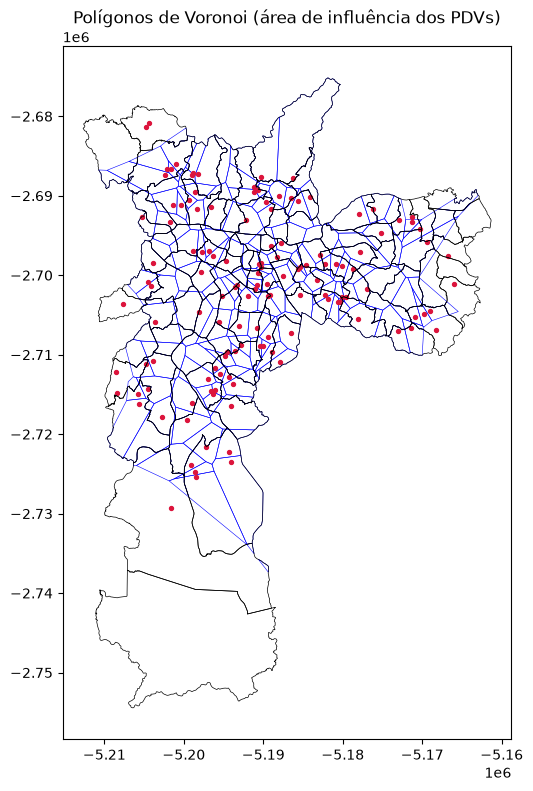

In [164]:
# Voronoi from PDVs (pontos de venda)
pts = np.array([(geom.x, geom.y) for geom in pontos_venda3857.geometry])
vor = Voronoi(pts)

polys = []
for region in vor.regions:
    if not region or -1 in region: 
        continue # non limited regions being discarted quietly
    polys.append(Polygon(vor.vertices[region]))

vor_gdf = gpd.GeoDataFrame(geometry=polys, crs=domicilios3857.crs)
vor_gdf = gpd.overlay(vor_gdf, localidade3857, how="intersection")

fig, ax = plt.subplots(figsize=(9, 9))
localidade3857.boundary.plot(ax=ax, color="black", linewidth=0.5)
vor_gdf.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=0.4)
pontos_venda3857.plot(ax=ax, color="crimson", markersize=8)
ax.set_title("Polígonos de Voronoi (área de influência dos PDVs)")
plt.show()

## Question 6: IDW interpolation
In IDW interpolation, increasing the power parameter causes:

#### Answer:
Increasing the power parameter causes the weight of closer points to increase and the weight of distant points to decrease more rapidly. In other words, the influence of nearest neighbors becomes dominant. This produces a surface with more abrupt transitions around each sample point ("bullseye" effect), reducing smoothing and making the estimate more local.

<br>

**pt-br**:

<span style="color:gray">
Aumentar o "power" faz os pontos mais próximos pesarem muito mais que os distantes, tornando a superfície mais "local" e com transições mais abruptas ao redor de cada amostra (menos suavização).

</span>

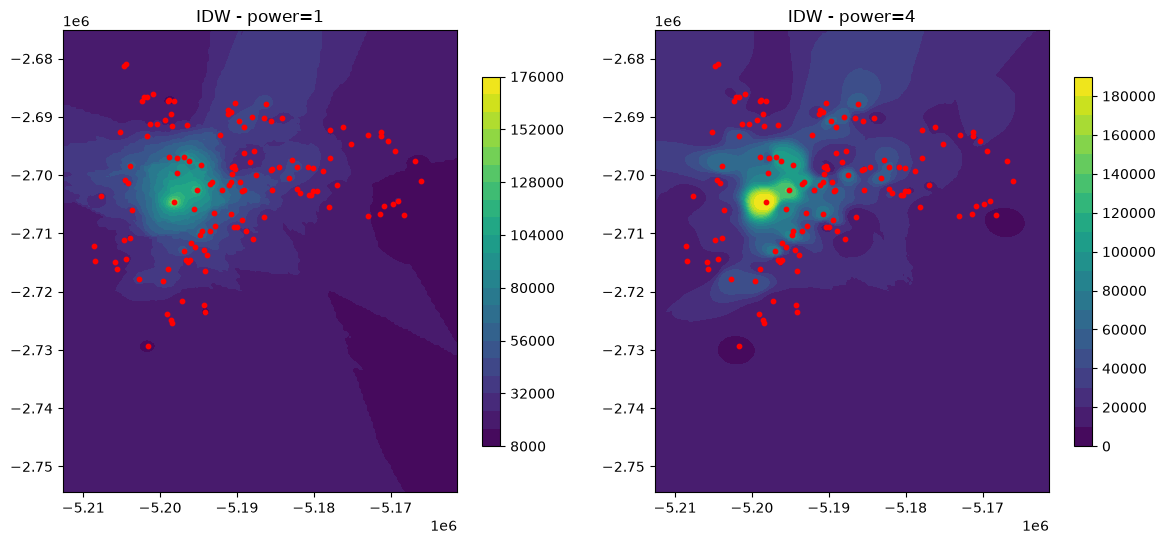

In [165]:
# IDW - comparison between 2 `power`
x = pontos_venda3857.geometry.x.values
y = pontos_venda3857.geometry.y.values
z = pontos_venda3857["FATURAM"].values

xmin, ymin, xmax, ymax = localidade3857.total_bounds
res = 200
grid_x, grid_y = np.meshgrid(np.linspace(xmin, xmax, res),
                              np.linspace(ymin, ymax, res))
grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))

tree = cKDTree(np.column_stack((x, y)))

def idw_interp(power, k=12):
    dist, idx = tree.query(grid_points, k=k)
    dist = np.where(dist == 0, 1e-6, dist)
    w = 1 / dist**power
    zi = (w * z[idx]).sum(axis=1) / w.sum(axis=1)
    return zi.reshape(grid_x.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, p in zip(axes, [1, 4]):
    zi = idw_interp(power=p)
    c = ax.contourf(grid_x, grid_y, zi, levels=20, cmap="viridis")
    ax.scatter(x, y, c="red", s=10)
    ax.set_title(f"IDW - power={p}")
    plt.colorbar(c, ax=ax, shrink=0.8)
plt.show()

## Question 7: Kriging
One advantage of Kriging over IDW is that it:

#### Answer:
The main advantage of Kriging over IDW is that it is a geostatistical interpolator based on the fitting of a variogram (which models the spatial dependence structure of the data), allowing for:
- Statistically optimized weights (not just an arbitrary function of distance, as in IDW)
- Providing an estimate of the uncertainty (error/variance) of the prediction at each point in space, something that IDW does not offer.

<br>

**pt-br**:

<span style="color:gray">
A Krigagem é um interpolador geoestatístico que modela a estrutura de dependência espacial dos dados via variograma, o que permite:

- pesos estatisticamente otimizados (não apenas função arbitrária da distância como no IDW) e 
- uma estimativa da incerteza/variância da predição em cada ponto, o IDW não fornece isso.

</span>

c:\Users\kel_m\anaconda3.12\envs\GeoStatistics\Lib\site-packages\pykrige\ok.py:663: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.581499229435235e-21.
  a_inv = scipy.linalg.inv(a)


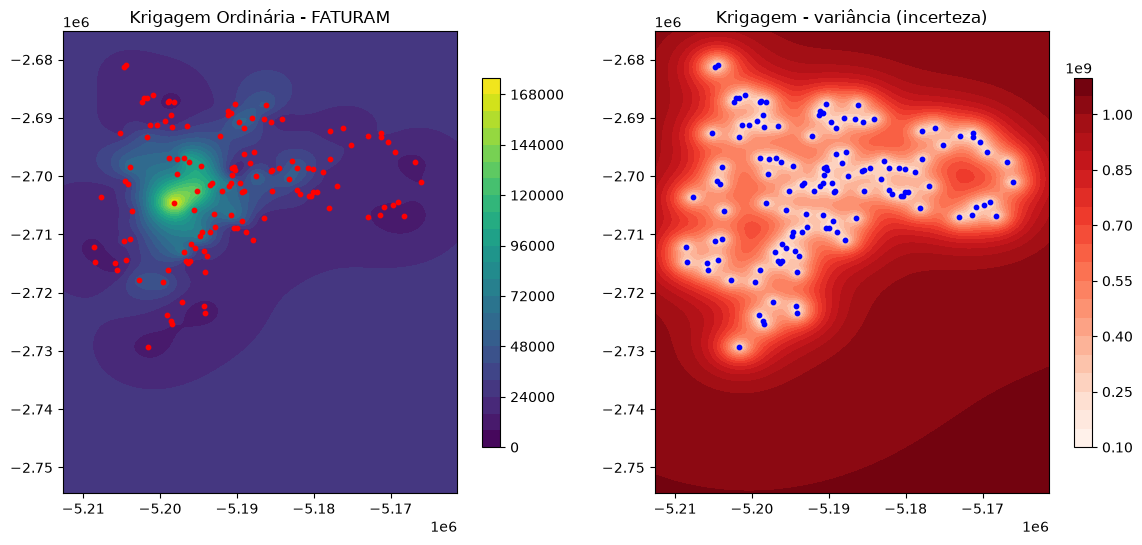

In [166]:
# Krigagem Ordinária
OK = OrdinaryKriging(
    x, y, z,
    variogram_model="exponential",
    verbose=False,
    enable_plotting=False)

gridx = np.linspace(xmin, xmax, 200)
gridy = np.linspace(ymin, ymax, 200)
z_krig, ss_krig = OK.execute("grid", gridx, gridy)  # ss_krig = variância (incerteza)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
c0 = axes[0].contourf(gridx, gridy, z_krig, levels=20, cmap="viridis")
axes[0].scatter(x, y, c="red", s=10)
axes[0].set_title("Krigagem Ordinária - FATURAM")
plt.colorbar(c0, ax=axes[0], shrink=0.8)

c1 = axes[1].contourf(gridx, gridy, ss_krig, levels=20, cmap="Reds")
axes[1].scatter(x, y, c="blue", s=10)
axes[1].set_title("Krigagem - variância (incerteza)")
plt.colorbar(c1, ax=axes[1], shrink=0.8)
plt.show()


In [167]:
# The warning above sometims indicates duplicated points or almost-coincidences 
# (2 stores almost in the same place), that would make variogram's covariance matrix
# almost singular. So let's check if there are any duplicates

dup = pontos_venda3857.geometry.duplicated().sum()
print(f"Pontos de venda com coordenadas duplicadas: {dup}")

Pontos de venda com coordenadas duplicadas: 0


#### Nota:
Sem duplicatas exatas; o warning provavelmente vem do range ajustado (~14.200 m) ser grande em relação à dispersão dos pontos, deixando a matriz de covariância mal-condicionada, isso não invalida a interpolação, mas a superfície de variância (incerteza) deve ser lida com cautela.

In [ ]:
# testing differnt variogram models
for model in ["linear", "gaussian", "spherical", "exponential"]:
    OK_test = OrdinaryKriging(x, y, z, variogram_model=model, verbose=False, enable_plotting=False)
    print(model, OK_test.variogram_model_parameters)

linear [3.45304393e-13 6.98709012e+08]
gaussian [6.39570106e+08 1.11781454e+00 4.72820202e+07]
spherical [9.20103494e+08 1.07339052e+04 6.45429583e+07]
exponential [9.20047681e+08 1.42086950e+04 6.45390922e+07]


## Question 8: Moran Index - Global
A positive and statistically significant Global Moran's I index indicates that:

#### Answer:
It indicates positive spatial autocorrelation: similar values ​​(high values ​​near high values, or low values ​​near low values) tend to cluster geographically, that is, there is spatial dependence; the value observed in one location is not independent of the value in neighboring locations.

<br>

**pt-br**:

<span style="color:gray">
Um Índice de Moran Global positivo e significativo indica autocorrelação espacial positiva: valores semelhantes (altos perto de altos, baixos perto de baixos) tendem a se agrupar no espaço, ou seja, existe dependência espacial nos dados.
</span>

In [169]:
# Domicílios by km² + Global Moran Index
join = gpd.sjoin(domicilios3857, localidade3857, predicate="within")
cont = join.groupby("index_right").size()
localidade3857["qtd"] = cont.reindex(localidade3857.index).fillna(0)
localidade3857["area_km2"] = localidade3857.area / 1e6
localidade3857["dens_km2"] = localidade3857["qtd"] / localidade3857["area_km2"]

w = Queen.from_dataframe(localidade3857, use_index=True)
print("Distritos sem vizinhos (ilhas):", w.islands)

w.transform = "r"

np.random.seed(42)
mi = Moran(localidade3857["dens_km2"], w)
print("Índice de Moran I  :", round(mi.I, 4))
print("p-valor (permutação):", mi.p_sim)


Distritos sem vizinhos (ilhas): []
Índice de Moran I  : 0.4116
p-valor (permutação): 0.001


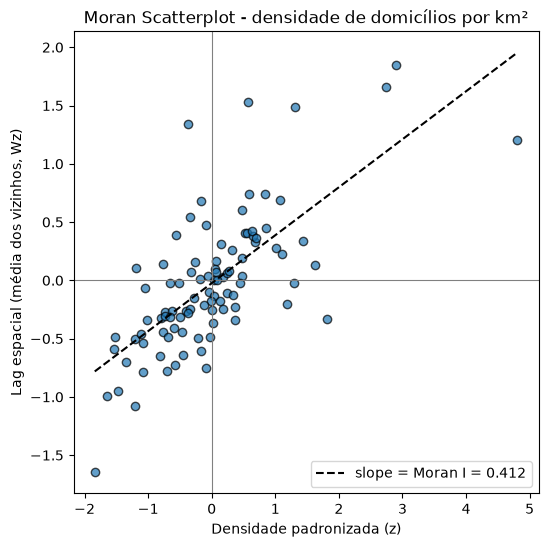

In [170]:
# Moran Scatterplot - visualização do Índice de Moran Global
from libpysal.weights import lag_spatial

z = (localidade3857["dens_km2"] - localidade3857["dens_km2"].mean()) / localidade3857["dens_km2"].std()
lag_z = lag_spatial(w, z)  # média espacial (ponderada pelos vizinhos Queen) do valor padronizado

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(z, lag_z, edgecolor="k", alpha=0.7)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)

# a inclinação (slope) da reta de regressão é, por definição, o próprio Índice de Moran I
b, a = np.polyfit(z, lag_z, 1)
xs = np.linspace(z.min(), z.max(), 10)
ax.plot(xs, a + b * xs, "k--", label=f"slope = Moran I = {mi.I:.3f}")

ax.set_xlabel("Densidade padronizada (z)")
ax.set_ylabel("Lag espacial (média dos vizinhos, Wz)")
ax.set_title("Moran Scatterplot - densidade de domicílios por km²")
ax.legend()
plt.show()

## Question 9: Moran Index - Local (LISA)
In a LISA map, a region classified as **High–High (HH)** represents:

#### Answer:
It represents a location with a high value, surrounded by neighbors that also have high values, that is, a cluster of high values, indicating a "hotspot" of concentration of the phenomenon studied.

<br>

**pt-br**:

<span style="color:gray">
Uma região High-High (HH) no mapa LISA representa um distrito com valor alto cercado por vizinhos também com valores altos, um cluster (agrupamento) de valores elevados, indicando uma "zona quente" (hotspot) do fenômeno estudado.
</span>

cluster_label
LL    41
HH    32
HL    12
LH    11
Name: count, dtype: int64


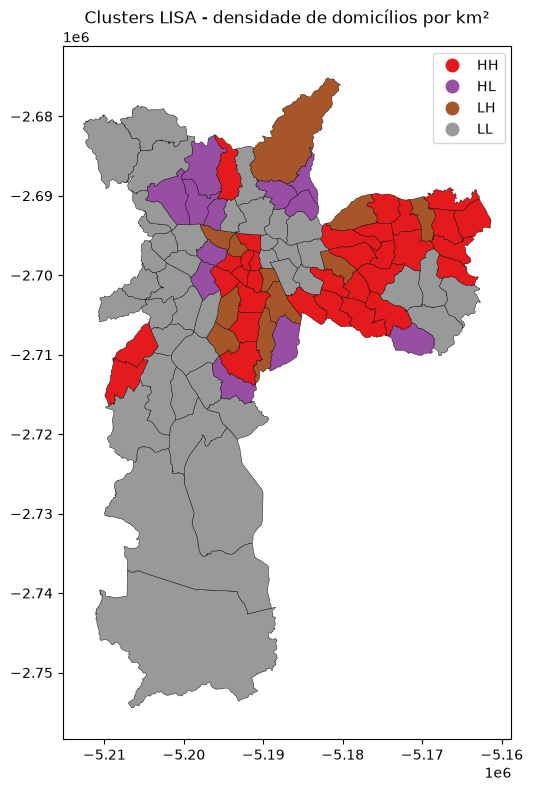

In [171]:
# LISA - Moran Local
lisa = Moran_Local(localidade3857["dens_km2"], w, seed=42)
localidade3857["cluster"] = lisa.q  # 1=HH, 2=LH, 3=LL, 4=HL

labels = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}
localidade3857["cluster_label"] = localidade3857["cluster"].map(labels)

print(localidade3857["cluster_label"].value_counts())

fig, ax = plt.subplots(figsize=(9, 9))
localidade3857.plot(column="cluster_label", categorical=True, legend=True,
                     cmap="Set1", ax=ax, edgecolor="black", linewidth=0.3)
ax.set_title("Clusters LISA - densidade de domicílios por km²")
plt.show()

## Question 10: Results
During spatial analysis, which technique is most suitable for answering the question:
"Is there spatial dependence between the observed values?"

#### Answer:
The most suitable technique is Spatial Autocorrelation Analysis via Moran's Index.
The Global Moran's Index is used to test whether there is spatial dependence in the area as a whole, complemented by the Local Moran's Index (LISA) to identify where specifically clusters (HH/LL clusters) or spatial anomalies (HL/LH outliers) occur.

<br>

**pt-br**:

<span style="color:gray">
Para responder "existe dependência espacial entre os valores observados?", a técnica mais indicada é a Análise de Autocorrelação Espacial via Índice de Moran: o Moran Global testa a existência de dependência espacial na área como um todo (uma única estatística + p-valor), e o Moran Local (LISA) complementa mostrando ONDE essa dependência se manifesta (clusters HH/LL e outliers HL/LH).

</span>

In [172]:
# Moran Global e Local juntos
print(f"Moran Global (I): {mi.I:.4f}  |  p-valor: {mi.p_sim:.4f}")
print("-> ", "HÁ dependência espacial significativa" if mi.p_sim < 0.05
      else "NÃO há evidência de dependência espacial")
print("\nDistribuição dos clusters LISA:")
print(localidade3857["cluster_label"].value_counts())

Moran Global (I): 0.4116  |  p-valor: 0.0010
->  HÁ dependência espacial significativa

Distribuição dos clusters LISA:
cluster_label
LL    41
HH    32
HL    12
LH    11
Name: count, dtype: int64


## Business Synthesis / Recommendations

Bringing together the Global/Local Moran's I results (household density clustering)
with actual PDV revenue by district, to translate the statistical findings into a
concrete network-expansion recommendation.

<br>

**pt-br**:

<span style="color:gray">
Reunindo os resultados do Moran Global/Local (agrupamento de densidade de domicílios)
com o faturamento real dos PDVs por distrito, para traduzir os achados estatísticos
em uma recomendação concreta de expansão da rede.
</span>

In [173]:
# Síntese de negócio - cruzando clusters LISA (densidade) com faturamento dos PDVs
# Objetivo: apontar distritos de alta densidade (cluster HH) que estão mal
# atendidos pela rede atual (sem PDV, ou PDV com faturamento abaixo da mediana),
# versus distritos HH já bem atendidos (reforçar/manter investimento).

# 1) Associa cada PDV ao distrito onde está localizado
pdv_distrito = gpd.sjoin(
    pontos_venda3857,
    localidade3857[["NM_DIST", "cluster_label", "dens_km2", "geometry"]],
    predicate="within",
    how="left"
)

# 2) Agrega faturamento por distrito
fat_distrito = pdv_distrito.groupby("NM_DIST").agg(
    n_pdv=("FATURAM", "count"),
    faturamento_medio=("FATURAM", "mean"),
    faturamento_total=("FATURAM", "sum")
).reset_index()

# 3) Junta de volta ao nível de distrito (inclui distritos sem nenhum PDV)
resumo = localidade3857[["NM_DIST", "dens_km2", "cluster_label"]].merge(
    fat_distrito, on="NM_DIST", how="left"
)
resumo["n_pdv"] = resumo["n_pdv"].fillna(0).astype(int)
resumo["faturamento_medio"] = resumo["faturamento_medio"].fillna(0)

mediana_fat = resumo.loc[resumo["n_pdv"] > 0, "faturamento_medio"].median()

def classifica(row):
    if row["cluster_label"] == "HH" and row["n_pdv"] == 0:
        return "1. Expansão prioritária (alta densidade, sem PDV)"
    elif row["cluster_label"] == "HH" and row["faturamento_medio"] < mediana_fat:
        return "2. Expansão/Reforço (alta densidade, PDV abaixo da mediana)"
    elif row["cluster_label"] == "HH" and row["faturamento_medio"] >= mediana_fat:
        return "3. Manter/Reforçar (alta densidade, já performando bem)"
    elif row["cluster_label"] == "LL":
        return "4. Baixa prioridade (baixa densidade)"
    else:
        return "5. Monitorar (cluster misto/outlier - HL ou LH)"

resumo["recomendacao"] = resumo.apply(classifica, axis=1)

# --- Resumo Moran Global + LISA (igual à célula 40, mantido para contexto) ---
print(f"Moran Global (I): {mi.I:.4f}  |  p-valor: {mi.p_sim:.4f}")
print("-> ", "HÁ dependência espacial significativa" if mi.p_sim < 0.05
      else "NÃO há evidência de dependência espacial")
print("\nDistribuição dos clusters LISA:")
print(localidade3857["cluster_label"].value_counts())

# --- Cruzamento de negócio: densidade x faturamento ---
print("\nRECOMENDAÇÕES POR DISTRITO")
print(resumo["recomendacao"].value_counts().sort_index())

print("\nDistritos de EXPANSÃO PRIORITÁRIA (alta densidade, sem PDV hoje):")
print(resumo[resumo["recomendacao"].str.startswith("1.")]
      [["NM_DIST", "dens_km2", "n_pdv"]]
      .sort_values("dens_km2", ascending=False))

print("\nDistritos para MANTER/REFORÇAR investimento (HH já performando bem):")
print(resumo[resumo["recomendacao"].str.startswith("3.")]
      [["NM_DIST", "dens_km2", "n_pdv", "faturamento_medio"]]
      .sort_values("faturamento_medio", ascending=False)
      .head(10))


Moran Global (I): 0.4116  |  p-valor: 0.0010
->  HÁ dependência espacial significativa

Distribuição dos clusters LISA:
cluster_label
LL    41
HH    32
HL    12
LH    11
Name: count, dtype: int64

RECOMENDAÇÕES POR DISTRITO
recomendacao
1. Expansão prioritária (alta densidade, sem PDV)              13
2. Expansão/Reforço (alta densidade, PDV abaixo da mediana)    12
3. Manter/Reforçar (alta densidade, já performando bem)         7
4. Baixa prioridade (baixa densidade)                          41
5. Monitorar (cluster misto/outlier - HL ou LH)                23
Name: count, dtype: int64

Distritos de EXPANSÃO PRIORITÁRIA (alta densidade, sem PDV hoje):
           NM_DIST   dens_km2  n_pdv
65       República  49.682066      0
6       Bela Vista  35.445774      0
16     Campo Limpo  21.384358      0
35  Itaim Paulista  20.076114      0
4      Artur Alvim  18.875841      0
43   Jardim Helena  18.610984      0
83     Vila Curuçá  17.353755      0
58           Penha  15.886730      0
30     

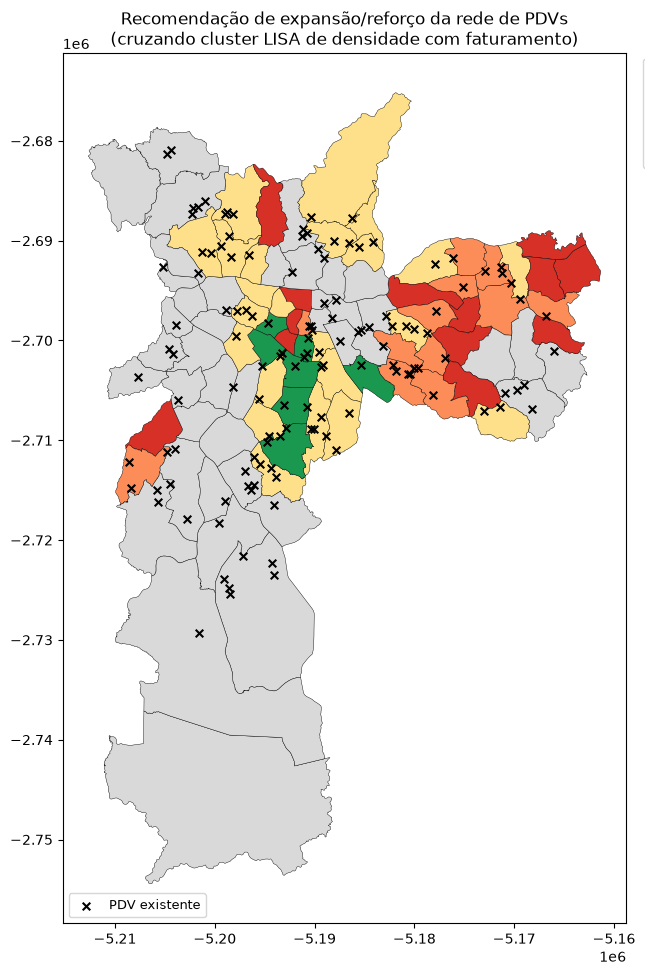

In [174]:
# Mapa das recomendações
mapa_resumo = localidade3857.merge(
    resumo[["NM_DIST", "recomendacao"]], on="NM_DIST"
)

# cores escolhidas manualmente, com significado (não depende de ordem alfabética do cmap)
color_map = {
    "1. Expansão prioritária (alta densidade, sem PDV)": "#d73027",            # vermelho forte = urgente
    "2. Expansão/Reforço (alta densidade, PDV abaixo da mediana)": "#fc8d59",  # laranja = atenção
    "3. Manter/Reforçar (alta densidade, já performando bem)": "#1a9850",      # verde = já vai bem
    "4. Baixa prioridade (baixa densidade)": "#d9d9d9",                        # cinza = baixa prioridade
    "5. Monitorar (cluster misto/outlier - HL ou LH)": "#fee08b",              # amarelo = observar
}

mapa_resumo["cor"] = mapa_resumo["recomendacao"].map(color_map)

fig, ax = plt.subplots(figsize=(10, 10))

mapa_resumo.plot(
    color=mapa_resumo["cor"],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

# legenda construída manualmente a partir do MESMO dicionário usado para colorir
legend_elements = [
    Patch(facecolor=cor, edgecolor="black", label=label)
    for label, cor in color_map.items()
]
legenda_categorias = ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    title="Recomendação",
    fontsize=8,
    title_fontsize=9
)

# marcador dos PDVs (segunda legenda)
ax.scatter(
    pontos_venda3857.geometry.x,
    pontos_venda3857.geometry.y,
    color="black",
    marker="x",
    s=30,
    label="PDV existente"
)
ax.legend(loc="lower left", fontsize=9)
ax.add_artist(legenda_categorias)

ax.set_title("Recomendação de expansão/reforço da rede de PDVs\n(cruzando cluster LISA de densidade com faturamento)")
plt.tight_layout()
plt.show()